### Note the downsampler classes tries to avoid copying data as much as possible. If you want to use data after the class is destroyed or modify it make sure to use `.copy()` or `copy` it yourself

In [6]:
from scdepth.bindings import Downsampler
from scdepth import fn, pl, fit
import os
import numpy as np
import pandas as pd
#Load the pre-processed example sample
sample = 'pbmc_1k_protein_v3'
prefix = f'../example/{sample}/scdepth'

full_summary = fn.parse_summary(prefix)

#basic tag counting and library information used throughout this example
full_summary

namespace(total_reads=66060721,
          spliced_reads=5731945,
          ambiguous_reads=17181428,
          unspliced_reads=10535774,
          countable_reads=33449147,
          low_quality_reads=23319508,
          bad_tag_reads=2156217,
          no_gene_reads=7135849,
          raw_molecules=9591626,
          bam='/media/data2/Genomics/Projects/Gavin/scdup/10X/raw/pbmc_1k_protein_v3_possorted_genome_bam.bam',
          min_gene=0.95,
          min_exonic=0.95,
          min_gene_bases=40,
          min_intronic=15,
          min_qual=255,
          discard_unknown_juncs=0,
          library_string='10X_3p_v3',
          barcode_tag='CB',
          barcode_length=18,
          barcode_regex='^[ACGT]+-\\d+$',
          umi_tag='UR',
          umi_length=12,
          strand_mode='fwd',
          barcodes_detected=304692)

In [7]:
#Should be the exclude file from the scdepth probes command
#this is only needed for probe based scrna, visium and visium HD samples
#ie {prefix}_exclude.txt
exclude_file = ''

#maximum RPM histogram size
max_hist = 50

#build the gene expression matrices for this example (not needed for depth planning etc)
build_matrices = True

#calculate spliced/ambiguous/unspliced quantificaitons
#this won't work for probe based assays
#this also isn't necessary if total counts are the only concern
calc_sau = True if exclude_file == '' else False

ds = Downsampler()
ds.init(prefix, max_hist=max_hist, build_matrices=build_matrices, exclude_file=exclude_file,
        calc_sau=calc_sau)

if not os.path.isfile(prefix + '_fit_baseline.txt'):
    print('scdepth fit must be run on the sample for this to work')

nbl, bstats, full_stats = fit.baseline_fitter(prefix)

#bstats has the baseline fit information plus a bunch of data from the full fit
print('bstats keys', bstats.keys())

#full_stats has information about the full depth data when the baseline saturation was used 
#by default this is 50% for samples with > 55% saturation
print('full stats keys', full_stats.keys())


bstats keys Index(['sample', 'fraction', 'reads', 'molecules', 'reads_discarded',
       'reads_excluded', 'spliced_reads', 'spliced_molecules',
       'ambiguous_reads', 'ambiguous_molecules', 'unspliced_reads',
       'unspliced_molecules', 'total_reads', 'total_molecules',
       'downsampled_frac', 'saturation', 'ztnb_rhat', 'ztnb_phat', 'ztnb_KS',
       'ztnb_nll_per_mol', 'ztnb_tail_mass', 'ztnb_error_flag', 'nb_lib_L',
       'nb_lib_saturation_MAE', 'nb_lib_recovery', 'countable_reads',
       'full_saturation', 'full_reads', 'full_molecules', 'spliced_ztnb_rhat',
       'spliced_ztnb_phat', 'spliced_ztnb_KS', 'spliced_ztnb_nll_per_mol',
       'spliced_ztnb_tail_mass', 'spliced_ztnb_error_flag', 'spliced_nb_lib_L',
       'ambiguous_ztnb_rhat', 'ambiguous_ztnb_phat', 'ambiguous_ztnb_KS',
       'ambiguous_ztnb_nll_per_mol', 'ambiguous_ztnb_tail_mass',
       'ambiguous_ztnb_error_flag', 'ambiguous_nb_lib_L',
       'unspliced_ztnb_rhat', 'unspliced_ztnb_phat', 'unspliced_ztnb

In [9]:
#read barcodes and emptydrops/tissue position data 
#read_barcodes_meta will automatically load tissue position and emptydrops data assuming they exist
barcodes = fn.read_barcodes_meta(ds, prefix)
genes = pd.read_csv(f'{prefix}_genes.txt.gz', sep='\t')

In [10]:
display(genes.head())

,gene_index,gene_id,gene_name
0,0,ENSG00000243485,MIR1302-2HG
1,1,ENSG00000237613,FAM138A
2,2,ENSG00000186092,OR4F5
3,3,ENSG00000238009,AL627309.1
4,4,ENSG00000239945,AL627309.3


In [12]:
display(barcodes.head())

,barcode,offset,seed,index,total,countable,raw_molecules,is_cell,passed
0,TTGTTGTAGTCATCGT-1,0,0,0,64955,37426,10755,1,1
1,CCGGTGAAGACATAAC-1,3298730556,0,1,185,29,9,0,0
2,TACGGGCGTCCCTGTT-1,3298730712,0,2,80052,36671,10036,1,1
3,CACAACACATTGACTG-1,8175294756,0,3,231,70,20,0,0
4,TCCCATGCAGAACTTC-1,8175295088,0,4,135423,93138,26392,1,1


In [13]:
#For visium HD the downsampler can be setup to bin data
if full_summary.library_string == 'visium_hd':
    total_rows = 3350
    total_cols = 3350
    ds.init_visium(rows=barcodes['array_row'].to_numpy(), cols=barcodes['array_col'].to_numpy(),
                in_tissue=barcodes['in_tissue'].to_numpy(), 
                countable=barcodes['countable'].to_numpy(), 
                total=barcodes['total'].to_numpy(), 
                total_rows=total_rows, total_cols=total_cols)


In [14]:
#the nbl fit can be used to get the countable reads necessary for different depths
#the fraction of reads for downsampling can also be calculated (downsampling only works when the fraction is <= 1.0)
align_rate = bstats.countable_reads / bstats.total_reads
recoveries = [50, 70, 90]
saturations = [50, 70, 90]
creads_recoveries = nbl.reads_for_recovery(recoveries)
creads_saturations = nbl.reads_for_saturation(saturations)


for c, r in zip(creads_recoveries, recoveries):
    print(f'Recovery = {r:.2f}% Countable Reads = {int(np.round(c)):,} Total Reads = {int(np.round(c/align_rate)):,}'
          f' fraction = {c/bstats.countable_reads:.2f}')
print('')
for c, s in zip(creads_saturations, saturations):
    print(f'Saturation = {s:.2f}% Countable Reads = {int(np.round(c)):,} Total Reads = {int(np.round(c/align_rate)):,}'
          f' fraction = {c/bstats.countable_reads:.2f}')

Recovery = 50.00% Countable Reads = 7,750,717 Total Reads = 15,307,355 fraction = 0.23
Recovery = 70.00% Countable Reads = 14,917,066 Total Reads = 29,460,605 fraction = 0.45
Recovery = 90.00% Countable Reads = 35,943,703 Total Reads = 70,987,369 fraction = 1.07

Saturation = 50.00% Countable Reads = 12,801,604 Total Reads = 25,282,654 fraction = 0.38
Saturation = 70.00% Countable Reads = 27,875,522 Total Reads = 55,053,035 fraction = 0.83
Saturation = 90.00% Countable Reads = 96,152,167 Total Reads = 189,896,666 fraction = 2.87


Text(0.5, 0, 'Sequenced Reads')

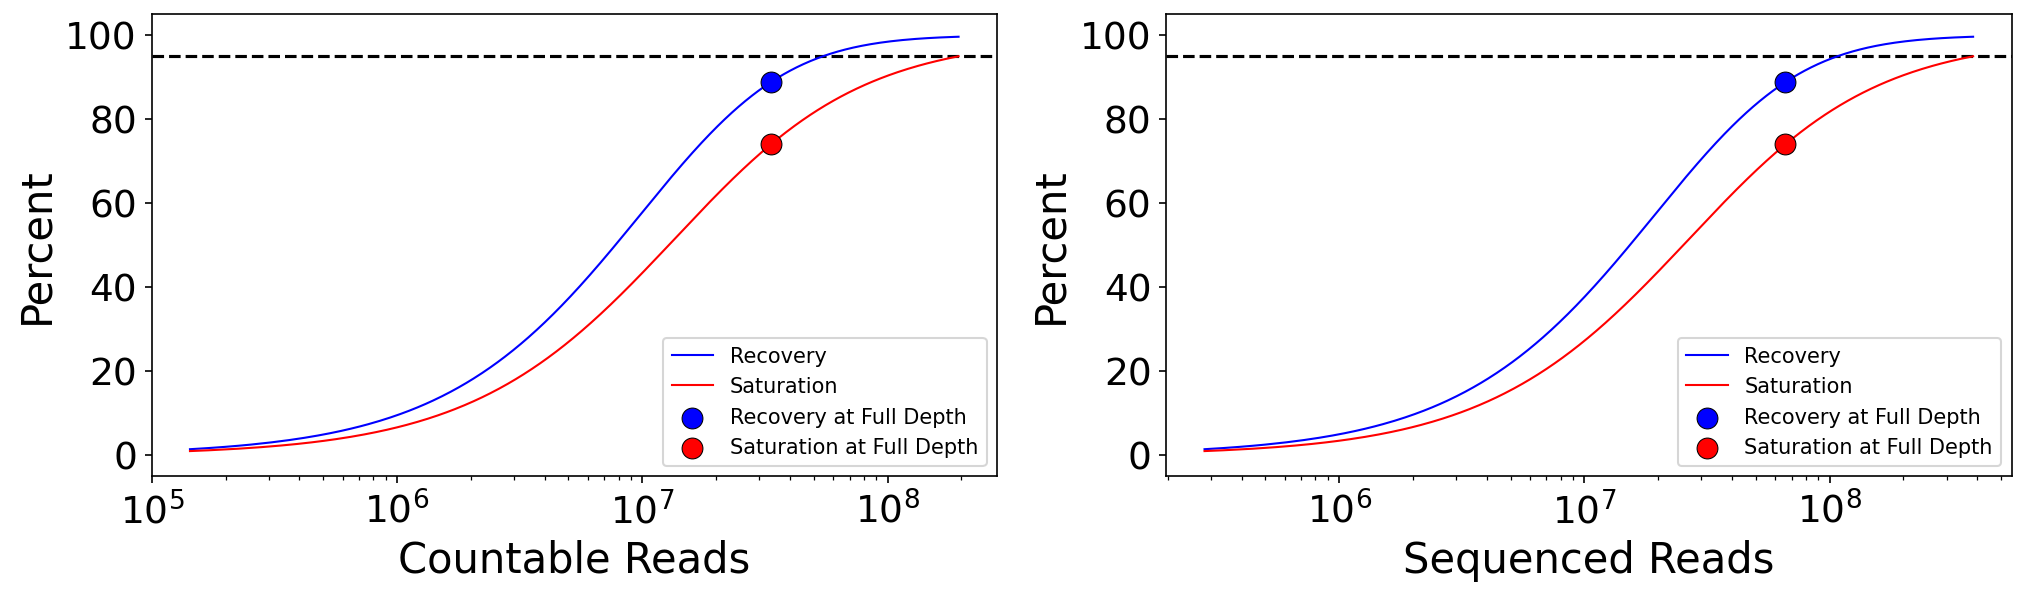

In [15]:
#plot saturation and recovery curves
fig, axs = pl.figax(1, 2, w=8, h=4)
sats = np.linspace(1, 95, 500)

reads = nbl.reads_for_saturation(sats)
recs = nbl.predict_recovery(reads)

for ax, scale in zip(axs, (1.0, align_rate)):
    #Mark saturation/recovery at full depth
    ax.plot(reads/scale, recs, lw=1, color='b', label='Recovery')
    ax.plot(reads/scale, sats, lw=1, color='r', label='Saturation')

    ax.scatter(full_summary.countable_reads/scale, nbl.predict_recovery(full_summary.countable_reads), 
                   zorder=5, s=100, color='b', edgecolor='k', lw=0.5, label='Recovery at Full Depth')
    
    ax.scatter(full_summary.countable_reads/scale, nbl.predict_saturation(full_summary.countable_reads), 
                   zorder=5, s=100, color='r', edgecolor='k', lw=0.5, label='Saturation at Full Depth')



for ax in axs:
    ax.set_ylabel('Percent', fontsize=20)
    ax.set_xscale('log')
    ax.axhline(95, ls='--', color='k', zorder=1)
    ax.tick_params(axis='both', labelsize=18)
    ax.set_ylim(-5, 105)
    ax.legend()
    
axs[0].set_xlabel('Countable Reads', fontsize=20)
axs[1].set_xlabel('Sequenced Reads', fontsize=20)


In [16]:
#Can also estimate the saturation at a given countable reads
print(f'Recovery at 1B Recovery = {nbl.predict_recovery(10**9):.2f}%')
print(f'Recovery at 1B Saturatiopn = {nbl.predict_saturation(10**9):.2f}%')

Recovery at 1B Recovery = 99.99%
Recovery at 1B Saturatiopn = 99.02%


In [17]:
#ZT-NB fit parameters
print(f'rhat = {nbl.rhat:.2f} phat = {nbl.phat:.2f} Lhat = {nbl.L:,.2f}')

rhat = 2.64 phat = 0.67 Lhat = 9,777,485.17


In [18]:
#downsampling to 25% and 50% of the total countable reads

#mutliple fractions can be specified this can become memory intensive
#when build matrices and calc_sau is enabled
fractions = [0.25, 0.5] 

#random downsampling seed
seed = 42

#only calculate the basic statistics needed (no barcodes etc)
aggregate_only = False

threads = 6 #downsampling threads
ds.downsample(fractions, umi_len=full_summary.umi_length, 
            seed=42, threads=threads, aggregate_only=aggregate_only)


True

In [19]:
#downsampling statistics
stats = fn.bulk_stats(ds, full_summary)
#predict recovery
stats['recovery'] = nbl.predict_recovery(stats['reads'])
stats

,fraction,reads,molecules,reads_discarded,reads_excluded,spliced_reads,spliced_molecules,ambiguous_reads,ambiguous_molecules,unspliced_reads,unspliced_molecules,total_reads,total_molecules,downsampled_frac,saturation,recovery
0,0.25,8340002,5105735,19019,0,1804828,989243,3897981,2492581,2637193,1623911,8340002,5105735,0.249902,38.780171,52.245229
1,0.50,16675649,7163468,46129,0,4000037,1492300,7389759,3376601,5285853,2294567,16675649,7163468,0.499916,57.042344,73.167251


baseline rhat = 2.64 phat = 0.67 Lhat = 9,777,485.17
Fraction = 0.250
  total rhat = 2.86 phat = 0.77 Lhat = 9,603,963.59
  class = spliced rhat = 7.41 phat = 0.86 Lhat = 1,444,536.65
  class = ambiguous rhat = 2.19 phat = 0.75 Lhat = 5,322,389.19
  class = unspliced rhat = 2.83 phat = 0.77 Lhat = 3,087,887.51
Fraction = 0.500
  total rhat = 2.50 phat = 0.60 Lhat = 9,888,531.17
  class = spliced rhat = 7.41 phat = 0.86 Lhat = 3,201,523.95
  class = ambiguous rhat = 2.19 phat = 0.75 Lhat = 10,090,139.85
  class = unspliced rhat = 2.83 phat = 0.77 Lhat = 6,189,201.72


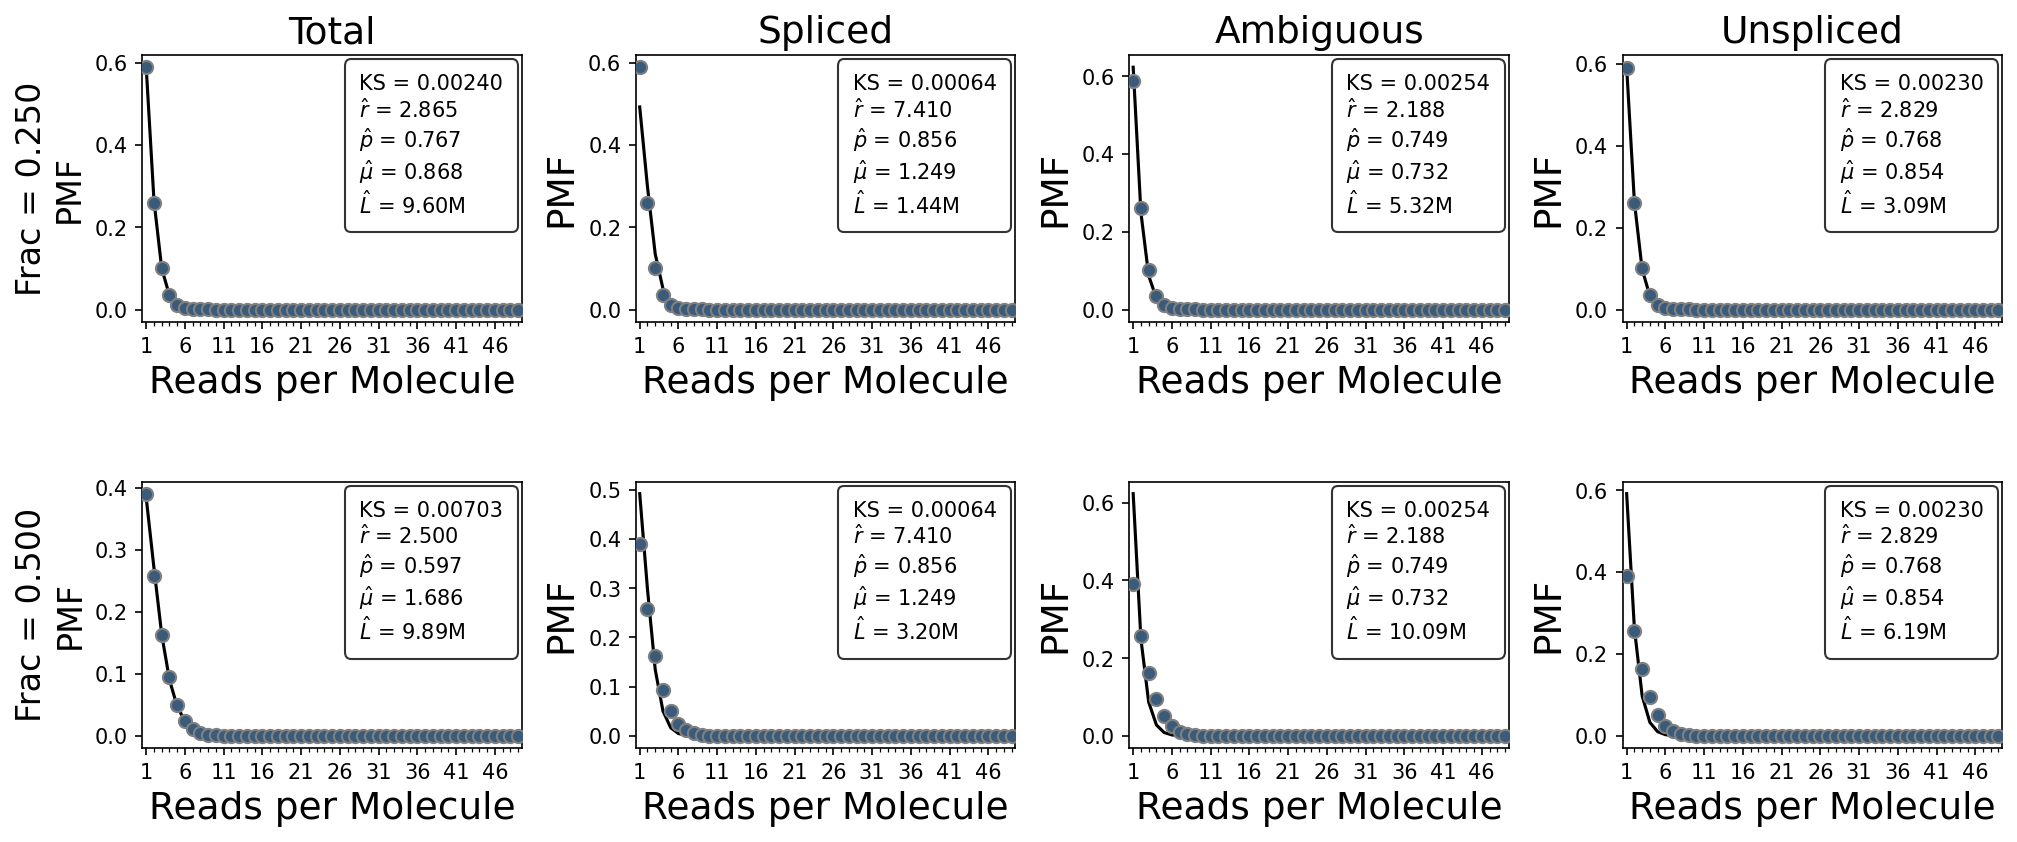

In [20]:
#get the histograms for each fraction and fit the ZT-NB

print(f'baseline rhat = {nbl.rhat:.2f} phat = {nbl.phat:.2f} Lhat = {nbl.L:,.2f}')
COLS = 1 if not calc_sau else 4

fig, axs = pl.figax(len(stats), COLS, w=4, h=3)
fig.subplots_adjust(hspace=0.6, wspace=0.3)
for rx, (i, r) in zip(axs, stats.iterrows()):
    if COLS == 1:
        ax = rx
    else:
        ax = rx[0]
    hist = fn.get_rpm_hist(ds=ds)[i]
    ff = fit.NBLibFit()
    ff.fit(hist, reads=r['reads'], molecules=r['molecules'])
    print(f'Fraction = {r.fraction:.3f}')
    print(f'  total rhat = {ff.rhat:.2f} phat = {ff.phat:.2f} Lhat = {ff.L:,.2f}')
    if i == 0:
        ax.set_title('Total', fontsize=18)
    pl.fits.plot_ztnb(ax, ff, hist, r, fs=10, lw=2, s=6, skip_legend=True)

    ax.set_ylabel(f'Frac = {r.fraction:.3f}\nPMF', fontsize=16)
                  
    if calc_sau:
        for k, ax in zip(fn.READ_CLASSES[:-1], rx[1:]):
            if i  == 0:
                ax.set_title(k.title(), fontsize=18)
            kr = r[f'{k}_reads']
            km = r[f'{k}_molecules']
            khist = fn.get_rpm_hist(ds, key=k)[0].copy()
            nbc = fit.NBLibFit()
            nbc.fit(khist, reads=kr, molecules=km)
            print(f'  class = {k} rhat = {nbc.rhat:.2f} phat = {nbc.phat:.2f} Lhat = {nbc.L:,.2f}')
            pl.fits.plot_ztnb(ax, nbc, hist, r, fs=10, lw=2, s=6, skip_legend=True)
    

In [21]:
#The downsampled data can be added to the barcodes dataframe
display(barcodes)
ds_bc = fn.barcode_df(ds, df=barcodes, step=0, key='total') #for total read classes

#for visium HD this dataframe can also be binned
bin_div = 0 #I used 8 for this in the manuscript ie 8x8 bins
if full_summary.library_string == 'visium_hd' and bin_div > 0:
    binned_df, _ = aggregate_visium_bins(ds, 0, bin_div, bin_div)
    cdf = pd.DataFrame(cdf)
    #these can be filtered for in_tissue etc and based on counts
    display(cdf)
    

,barcode,offset,seed,index,total,countable,raw_molecules,is_cell,passed
0,TTGTTGTAGTCATCGT-1,0,0,0,64955,37426,10755,1,1
1,CCGGTGAAGACATAAC-1,3298730556,0,1,185,29,9,0,0
2,TACGGGCGTCCCTGTT-1,3298730712,0,2,80052,36671,10036,1,1
3,CACAACACATTGACTG-1,8175294756,0,3,231,70,20,0,0
4,TCCCATGCAGAACTTC-1,8175295088,0,4,135423,93138,26392,1,1
...,...,...,...,...,...,...,...,...,...
304687,TTTGTTGTCTCTAGCT-1,3896026856012,0,304687,2,0,0,0,0
304688,TTTGTTGTCTGCATAG-1,3896026856012,0,304688,1,0,0,0,0
304689,TTTGTTGTCTGGAAGG-1,3896026856012,0,304689,1,0,0,0,0
304690,TTTGTTGTCTTCTCAA-1,3896026856012,0,304690,1,0,0,0,0


In [22]:
#Filter for cells / tissue spots only
kidx = np.where(barcodes['passed'] == 1)[0]

In [28]:
import anndata as ad

#total count CSR matrices can be retrieved with
#ds.total_csr or ds.total_csr_bin 
#total_csr_bin is used for Visium HD binning only 
step = 0 # use the first downsampling fraction
bin_div = 0 #I used 8 for this in the manuscript ie 8x8 bins
if full_summary.library_string == 'visium_hd' and bin_div > 0:
    X = ds.total_csr_bin(step, bin_div)
else:
    X = ds.total_csr(step)

#Filter the barcodes
X = X[kidx]
var = genes.copy()
var.index = var['gene_id'].astype(str)
#this can be used with scanpy now and is downsampled to 25%
#barcodes may need to be further filtered since this was done at 25% read depth
adata = ad.AnnData(X=X, obs=barcodes.iloc[kidx].copy(), var=genes)
adata

Test indptr 304693 indices 2123698 data 2123698 barcodes 304692 genes 33538


/home/gww/micromamba/envs/GWW/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/gww/micromamba/envs/GWW/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 628 × 33538
    obs: 'barcode', 'offset', 'seed', 'index', 'total', 'countable', 'raw_molecules', 'is_cell', 'passed', 'reads', 'molecules', 'genes', 'discarded_reads'
    var: 'gene_index', 'gene_id', 'gene_name'

In [30]:
#other matrices can be retrieved
if calc_sau:
    Xs = ds.spliced_csr(step)
    print(Xs.shape)
    Xu = ds.unspliced_csr(step)
    print(Xs.shape)
    Xa = ds.ambiguous_csr(step)
    print(Xs.shape)

(304692, 33538)
(304692, 33538)
(304692, 33538)
